In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# 1. Cargar la imagen
imagen_bgr = cv2.imread('imagenes/r2d2_urdf.png')
if imagen_bgr is None:
    raise FileNotFoundError("No se pudo cargar la imagen. Verifica el nombre y la ruta.")

In [10]:
# 2. Convertir a HSV
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

In [11]:
# 3. Definir el rango para el color azul (cuerpo del robot)
rango_bajo = np.array([100, 100, 50])   # valores aproximados para azul
rango_alto = np.array([130, 255, 255])


In [12]:
# 4. Crear máscara binaria
mascara = cv2.inRange(imagen_hsv, rango_bajo, rango_alto)

In [13]:
# 5. Encontrar contornos
contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Centroide detectado en píxeles: (654, 623)


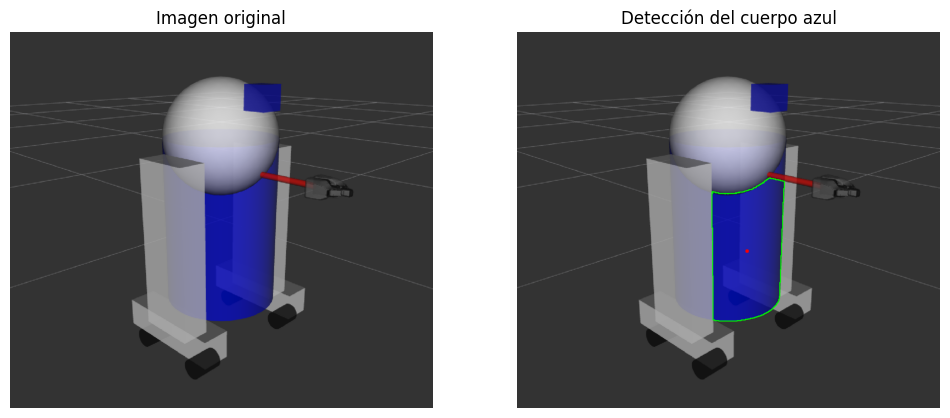

In [14]:
if not contornos:
    print("No se detectó ningún objeto azul.")
else:
    # 6. Tomar el contorno más grande (mayor área)
    mayor = max(contornos, key=cv2.contourArea)

    # 7. Calcular centroide
    M = cv2.moments(mayor)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        print(f"Centroide detectado en píxeles: ({cx}, {cy})")
    else:
        cx, cy = 0, 0
        print("No se pudo calcular el centroide.")

    # 8. Dibujar resultado
    resultado = imagen_bgr.copy()
    cv2.drawContours(resultado, [mayor], -1, (0, 255, 0), 2)
    cv2.circle(resultado, (cx, cy), 5, (0, 0, 255), -1)

    # 9. Mostrar imágenes
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
    plt.title('Imagen original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title('Detección del cuerpo azul')
    plt.axis('off')
    plt.show()